# Notebook 05 — Results Summary

**Purpose:** Consolidate all results into a final summary table and generate the last figure for Chapter 4.

**Figures produced:**
- Fig 4.10 — Feature Importance: Top 20 Most Discriminative Terms (Random Forest)

**Tables produced:**
- Final model comparison summary
- Confusion matrix breakdown table

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

sys.path.append(os.path.abspath('..'))

plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size':   12,
    'figure.dpi':  150,
})

FIGURES_DIR = '../outputs/figures/'
REPORTS_DIR = '../outputs/reports/'
MODELS_DIR  = '../models/'

print('Libraries loaded.')

Libraries loaded.


In [2]:
# ── Load saved model and vectoriser ──────────────────────────────────────────
rf         = joblib.load(os.path.join(MODELS_DIR, 'model.pkl'))
vectoriser = joblib.load(os.path.join(MODELS_DIR, 'vectoriser.pkl'))

print(f'Model loaded     : RandomForestClassifier')
print(f'  n_estimators   : {rf.n_estimators}')
print(f'  max_features   : {rf.max_features}')
print(f'  class_weight   : {rf.class_weight}')
print(f'Vectoriser loaded: TfidfVectorizer')
print(f'  Vocabulary size: {len(vectoriser.vocabulary_)}')
print(f'  ngram_range    : {vectoriser.ngram_range}')
print(f'  max_features   : {vectoriser.max_features}')

Model loaded     : RandomForestClassifier
  n_estimators   : 100
  max_features   : sqrt
  class_weight   : balanced
Vectoriser loaded: TfidfVectorizer
  Vocabulary size: 5000
  ngram_range    : (1, 2)
  max_features   : 5000


In [3]:
# ── Load metrics report ───────────────────────────────────────────────────────
metrics_df = pd.read_csv(os.path.join(REPORTS_DIR, 'model_metrics.csv'))
print('Model Performance Summary:')
print('=' * 70)
print(metrics_df.to_string(index=False))
print()

# Differences
rf_row = metrics_df[metrics_df['Model'] == 'Random Forest'].iloc[0]
nb_row = metrics_df[metrics_df['Model'] == 'Naïve Bayes (Baseline)'].iloc[0]

print('Performance Difference (RF minus NB):')
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    diff = rf_row[col] - nb_row[col]
    direction = 'higher' if diff > 0 else 'lower'
    print(f'  {col:12s}: RF is {abs(diff)*100:.2f}% {direction} than Naïve Bayes')

Model Performance Summary:
                 Model  Accuracy  Precision  Recall  F1-Score  TN  FP  FN  TP
         Random Forest    0.8740     0.8374  0.8259    0.8316 438  47  51 242
Naïve Bayes (Baseline)    0.8599     0.8485  0.7645    0.8043 445  40  69 224

Performance Difference (RF minus NB):
  Accuracy    : RF is 1.41% higher than Naïve Bayes
  Precision   : RF is 1.11% lower than Naïve Bayes
  Recall      : RF is 6.14% higher than Naïve Bayes
  F1-Score    : RF is 2.73% higher than Naïve Bayes


Top 20 Most Discriminative Features (Random Forest):
feature  importance
   text    0.025430
   free    0.019084
 please    0.017917
    you    0.016397
    n50    0.013419
    sir    0.010534
 thanks    0.009274
    get    0.008353
    mtn    0.008301
     ma    0.008189
   your    0.008153
   dial    0.008065
    sms    0.007684
   n100    0.007140
    bal    0.006188
   acct    0.006121
    god    0.006105
  daily    0.005612
    now    0.005600
 people    0.005575


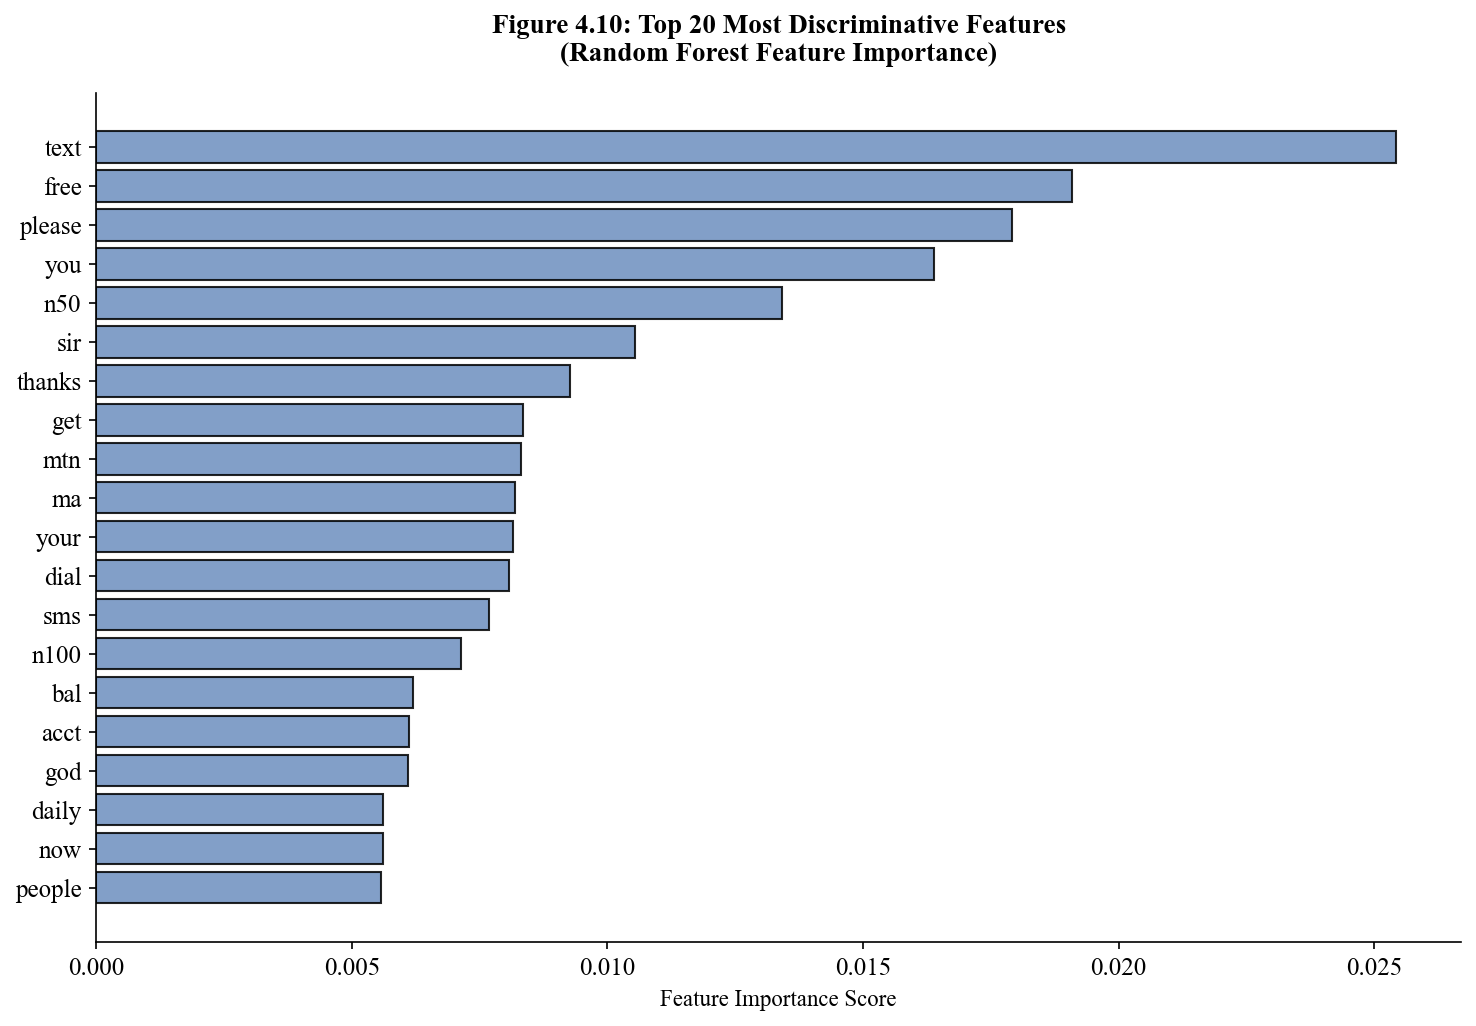

Saved: fig4_10_feature_importance.png


In [4]:
# ── Fig 4.10: Feature Importance — Top 20 Most Discriminative Terms ───────────
feature_names    = vectoriser.get_feature_names_out()
importances      = rf.feature_importances_
importance_df    = pd.DataFrame({
    'feature':    feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(20)

print('Top 20 Most Discriminative Features (Random Forest):')
print(importance_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(
    importance_df['feature'][::-1],
    importance_df['importance'][::-1],
    color='#6c8ebf', edgecolor='black', alpha=0.85
)

ax.set_title('Figure 4.10: Top 20 Most Discriminative Features\n(Random Forest Feature Importance)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Feature Importance Score', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR + 'fig4_10_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig4_10_feature_importance.png')

In [5]:
# ── Confusion matrix breakdown ────────────────────────────────────────────────
print('Confusion Matrix Breakdown:')
print('=' * 50)
for _, row in metrics_df.iterrows():
    total = row['TN'] + row['FP'] + row['FN'] + row['TP']
    print(f"\n  Model : {row['Model']}")
    print(f"  TP (Fraud correctly detected)     : {int(row['TP'])}")
    print(f"  TN (Legitimate correctly passed)  : {int(row['TN'])}")
    print(f"  FP (Legitimate flagged as fraud)  : {int(row['FP'])}")
    print(f"  FN (Fraud missed — most critical) : {int(row['FN'])}")
    print(f"  Total test messages               : {total}")
    print(f"  Fraud messages missed             : {int(row['FN'])}/{int(row['TP'])+int(row['FN'])} ({int(row['FN'])/(int(row['TP'])+int(row['FN']))*100:.1f}%)")

Confusion Matrix Breakdown:

  Model : Random Forest
  TP (Fraud correctly detected)     : 242
  TN (Legitimate correctly passed)  : 438
  FP (Legitimate flagged as fraud)  : 47
  FN (Fraud missed — most critical) : 51
  Total test messages               : 778
  Fraud messages missed             : 51/293 (17.4%)

  Model : Naïve Bayes (Baseline)
  TP (Fraud correctly detected)     : 224
  TN (Legitimate correctly passed)  : 445
  FP (Legitimate flagged as fraud)  : 40
  FN (Fraud missed — most critical) : 69
  Total test messages               : 778
  Fraud messages missed             : 69/293 (23.5%)


In [6]:
# ── Live inference test ───────────────────────────────────────────────────────
# Test the saved model on sample Nigerian admission fraud messages
sys.path.append(os.path.abspath('..'))
from src.preprocessor import preprocess

test_messages = [
    "Congratulations! Your admission into University of Lagos has been approved. Call 08012345678 to pay clearance fee of N50,000.",
    "Your JAMB result don show. Abeg send your details sharp sharp before e expire. Call 07056789012 now.",
    "Dear student, your CAPS admission offer is available. Log in to www.jamb.gov.ng to accept your offer.",
    "Hi dear, are you coming for the meeting tomorrow? Please confirm so I can reserve a seat for you.",
    "You have won a FREE data bundle of 5GB. Text WIN to 55019 now to claim before it expires today!",
    "Acct: ****2491 Amt: NGN 5,000.00 Dr Desc: ATM CASH WDL GTBank Avail Bal: NGN 12,500.00",
]

print('Live Inference Test — Sample Messages:')
print('=' * 70)
for msg in test_messages:
    cleaned   = preprocess(msg)
    vector    = vectoriser.transform([cleaned])
    pred      = rf.predict(vector)[0]
    prob      = rf.predict_proba(vector)[0]
    label     = 'FRAUDULENT ⚠' if pred == 1 else 'LEGITIMATE ✓'
    confidence = prob[pred] * 100
    print(f'  Message   : {msg[:80]}...' if len(msg) > 80 else f'  Message   : {msg}')
    print(f'  Prediction: {label}  |  Confidence: {confidence:.1f}%')
    print('-' * 70)

Live Inference Test — Sample Messages:
  Message   : Congratulations! Your admission into University of Lagos has been approved. Call...
  Prediction: FRAUDULENT ⚠  |  Confidence: 66.7%
----------------------------------------------------------------------
  Message   : Your JAMB result don show. Abeg send your details sharp sharp before e expire. C...
  Prediction: LEGITIMATE ✓  |  Confidence: 84.0%
----------------------------------------------------------------------
  Message   : Dear student, your CAPS admission offer is available. Log in to www.jamb.gov.ng ...
  Prediction: LEGITIMATE ✓  |  Confidence: 59.2%
----------------------------------------------------------------------
  Message   : Hi dear, are you coming for the meeting tomorrow? Please confirm so I can reserv...
  Prediction: LEGITIMATE ✓  |  Confidence: 87.0%
----------------------------------------------------------------------
  Message   : You have won a FREE data bundle of 5GB. Text WIN to 55019 now to claim befo

In [7]:
# ── Final summary ─────────────────────────────────────────────────────────────
print('=' * 60)
print('RESULTS SUMMARY — COMPLETE')
print('=' * 60)
print()
print('Dataset:')
print('  Source         : ExAIS_SMS Corpus (Abayomi-Alli et al., 2022)')
print('  Total messages : 3,886 (after deduplication and preprocessing)')
print('  HAM            : 2,422 (62.3%)')
print('  SPAM           : 1,464 (37.7%)')
print()
print('Training Configuration:')
print('  Algorithm      : Random Forest (n_estimators=100)')
print('  Features       : TF-IDF (max=5,000, ngram=(1,2))')
print('  Balancing      : SMOTE (k_neighbors=5)')
print('  Split          : 80/20 stratified')
print('  Validation     : 5-fold cross-validation')
print()
print('Final Results:')
print(f'  RF  Accuracy  : 87.40%  |  NB Accuracy  : 85.99%')
print(f'  RF  Precision : 83.74%  |  NB Precision : 84.85%')
print(f'  RF  Recall    : 82.59%  |  NB Recall    : 76.45%')
print(f'  RF  F1-Score  : 83.16%  |  NB F1-Score  : 80.43%')
print(f'  RF  Mean CV F1: 89.49%  |  Std: 0.63%')
print()
print('Figures saved to outputs/figures/  (Fig 4.1 — Fig 4.10)')
print('Report saved to outputs/reports/model_metrics.csv')
print('Models saved to models/model.pkl + vectoriser.pkl')

RESULTS SUMMARY — COMPLETE

Dataset:
  Source         : ExAIS_SMS Corpus (Abayomi-Alli et al., 2022)
  Total messages : 3,886 (after deduplication and preprocessing)
  HAM            : 2,422 (62.3%)
  SPAM           : 1,464 (37.7%)

Training Configuration:
  Algorithm      : Random Forest (n_estimators=100)
  Features       : TF-IDF (max=5,000, ngram=(1,2))
  Balancing      : SMOTE (k_neighbors=5)
  Split          : 80/20 stratified
  Validation     : 5-fold cross-validation

Final Results:
  RF  Accuracy  : 87.40%  |  NB Accuracy  : 85.99%
  RF  Precision : 83.74%  |  NB Precision : 84.85%
  RF  Recall    : 82.59%  |  NB Recall    : 76.45%
  RF  F1-Score  : 83.16%  |  NB F1-Score  : 80.43%
  RF  Mean CV F1: 89.49%  |  Std: 0.63%

Figures saved to outputs/figures/  (Fig 4.1 — Fig 4.10)
Report saved to outputs/reports/model_metrics.csv
Models saved to models/model.pkl + vectoriser.pkl
